In [ ]:
!pip install transformers
!pip install scikit-learn
!pip install langdetect
!pip install pandas
!pip install transformers langdetect scikit-learn -q

Using Device: cuda


Saving emotion_hinghlish_dataset.csv to emotion_hinghlish_dataset (7).csv
Saving sarcasm_hinghlish_dataset.csv to sarcasm_hinghlish_dataset (7).csv


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Loss: 267.96 | Accuracy: 89.84%
Epoch 2 | Loss: 125.90 | Accuracy: 94.42%
Epoch 3 | Loss: 95.82 | Accuracy: 95.10%
Epoch 4 | Loss: 75.11 | Accuracy: 96.43%
Epoch 5 | Loss: 60.63 | Accuracy: 97.13%


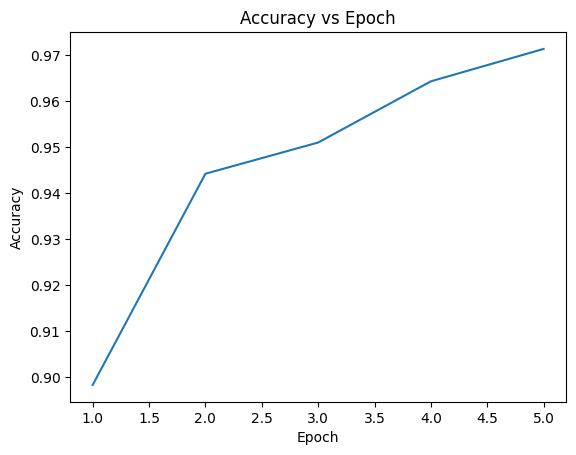

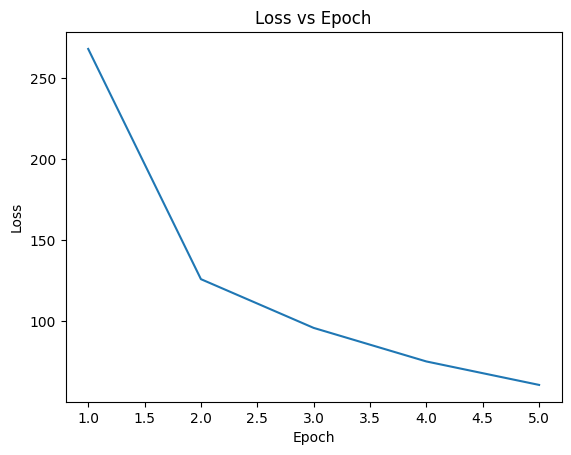


📊 FINAL MODEL COMPARISON
------------------------------------------------
SVM Accuracy         : 93.64%
Logistic Accuracy    : 92.81%
XLM-R Hybrid Accuracy: 95.41%


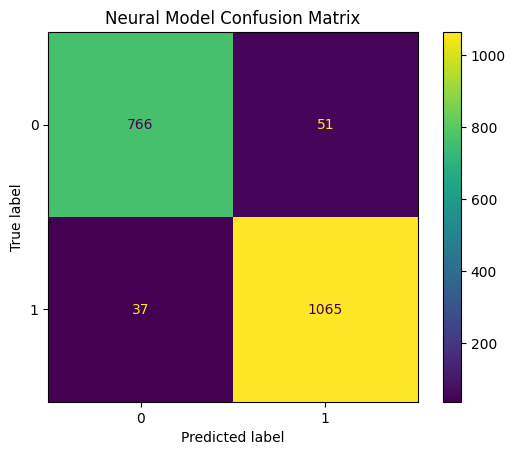

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       817
           1       0.95      0.97      0.96      1102

    accuracy                           0.95      1919
   macro avg       0.95      0.95      0.95      1919
weighted avg       0.95      0.95      0.95      1919



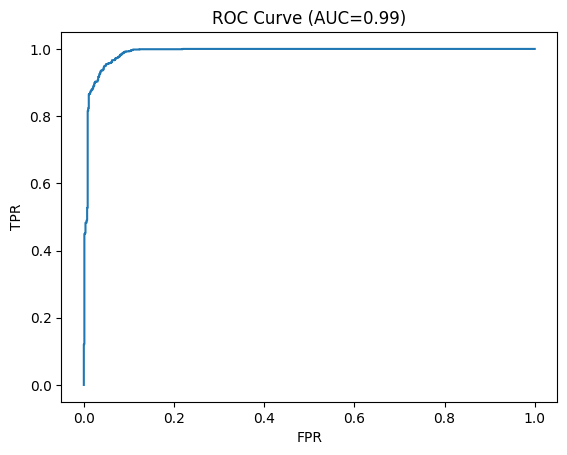

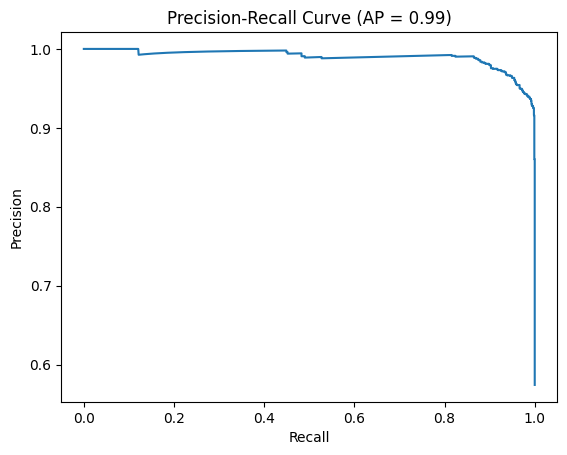


🔍 INPUT ANALYSIS REPORT
------------------------------------------------
Text        : wow great job failing again
Language    : en
Final Class : ✅ Sarcastic
Confidence  : 100.0%


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import re
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from langdetect import detect
from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# =========================================================
# 📂 Upload Datasets
# =========================================================
uploaded = files.upload()

def safe_read(file):
    return pd.read_csv(file, engine="python",
                       encoding_errors="ignore",
                       sep=",",
                       on_bad_lines="skip")

sarcasm_df = safe_read("sarcasm_hinghlish_dataset.csv")
emotion_df = safe_read("emotion_hinghlish_dataset.csv")

# =========================================================
# AUTO DETECT COLUMNS
# =========================================================
def find_text_column(df):
    for col in df.columns:
        if any(k in col.lower() for k in ["text","tweet","sentence"]):
            return col
    return df.columns[0]

def find_label_column(df):
    for col in df.columns:
        if any(k in col.lower() for k in ["label","class","target","emotion"]):
            return col
    return df.columns[-1]

sarcasm_text_col = find_text_column(sarcasm_df)
sarcasm_label_col = find_label_column(sarcasm_df)
emotion_text_col = find_text_column(emotion_df)
emotion_label_col = find_label_column(emotion_df)

# =========================================================
# PREPROCESSING
# =========================================================
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

sarcasm_df[sarcasm_text_col] = sarcasm_df[sarcasm_text_col].apply(preprocess)
emotion_df[emotion_text_col] = emotion_df[emotion_text_col].apply(preprocess)

sarcasm_df = sarcasm_df.dropna()
emotion_df = emotion_df.dropna()

# =========================================================
# EMOTION ENCODING
# =========================================================
emotion_dict = {}
for i in range(len(emotion_df)):
    words = emotion_df.iloc[i][emotion_text_col].split()
    label = str(emotion_df.iloc[i][emotion_label_col]).lower()
    score = -1 if label in ["sad","angry","negative","fear"] else 1
    for w in words:
        emotion_dict[w] = score

def emotion_score(text):
    return sum(emotion_dict.get(w, 0) for w in text.split())

# =========================================================
# TF-IDF FEATURES
# =========================================================
tfidf_word = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
tfidf_char = TfidfVectorizer(analyzer="char", ngram_range=(3,5), max_features=3000)

X_word = tfidf_word.fit_transform(sarcasm_df[sarcasm_text_col])
X_char = tfidf_char.fit_transform(sarcasm_df[sarcasm_text_col])

X_tfidf = np.hstack((X_word.toarray(), X_char.toarray()))
y = sarcasm_df[sarcasm_label_col]

X_train_text, X_test_text, y_train, y_test, tfidf_train, tfidf_test = train_test_split(
    sarcasm_df[sarcasm_text_col], y, X_tfidf,
    test_size=0.2, random_state=42)

# =========================================================
# HYBRID MODEL
# =========================================================
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = AutoModel.from_pretrained("xlm-roberta-base")
        self.lstm = nn.LSTM(768,256,batch_first=True,bidirectional=True)
        self.attention = nn.MultiheadAttention(512,4,batch_first=True)
        self.emotion_fc = nn.Linear(1,32)
        self.fc = nn.Linear(512+32,1)

    def forward(self,input_ids,attention_mask,emotion):
        out = self.transformer(input_ids=input_ids,
                               attention_mask=attention_mask)
        x = out.last_hidden_state
        x,_ = self.lstm(x)
        x,_ = self.attention(x,x,x)
        x = torch.mean(x,dim=1)
        emotion = torch.relu(self.emotion_fc(emotion.unsqueeze(1)))
        x = torch.cat((x,emotion),dim=1)
        return torch.sigmoid(self.fc(x))

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = HybridModel().to(device)

# Freeze early layers
for name, param in model.transformer.named_parameters():
    if "encoder.layer.0" in name or "encoder.layer.1" in name:
        param.requires_grad = False

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.BCELoss()

batch_size = 8
train_data = list(zip(X_train_text.tolist(), y_train.tolist()))

total_steps = len(train_data)//batch_size * 5
scheduler = get_linear_schedule_with_warmup(optimizer,0,total_steps)

# =========================================================
# TRAINING
# =========================================================
epoch_losses = []
epoch_accuracies = []

for epoch in range(5):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for i in range(0, len(train_data), batch_size):
        batch = train_data[i:i+batch_size]
        texts = [x[0] for x in batch]
        labels = torch.tensor([x[1] for x in batch],
                              dtype=torch.float).to(device)

        enc = tokenizer(texts,padding=True,truncation=True,
                        return_tensors="pt",max_length=128).to(device)

        emotions = torch.tensor([emotion_score(t) for t in texts],
                                dtype=torch.float).to(device)

        optimizer.zero_grad()
        outputs = model(enc["input_ids"],
                        enc["attention_mask"],
                        emotions).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = (outputs>0.5).float()
        correct += (preds==labels).sum().item()
        total += labels.size(0)

    acc = correct/total
    epoch_losses.append(total_loss)
    epoch_accuracies.append(acc)
    print(f"Epoch {epoch+1} | Loss: {total_loss:.2f} | Accuracy: {acc*100:.2f}%")

# =========================================================
# GRAPHS
# =========================================================
plt.figure()
plt.plot(range(1,6), epoch_accuracies)
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(range(1,6), epoch_losses)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# =========================================================
# NEURAL ACCURACY
# =========================================================
model.eval()
nn_preds=[]
nn_probs=[]

for text in X_test_text:
    enc = tokenizer(text,return_tensors="pt",
                    truncation=True,max_length=128).to(device)
    emotion=torch.tensor([emotion_score(text)],
                         dtype=torch.float).to(device)
    with torch.no_grad():
        prob=model(enc["input_ids"],
                   enc["attention_mask"],
                   emotion).item()
    nn_probs.append(prob)
    nn_preds.append(1 if prob>0.5 else 0)

nn_acc = accuracy_score(y_test, nn_preds)

# =========================================================
# CLASSICAL MODELS
# =========================================================
svm=LinearSVC()
lr=LogisticRegression(max_iter=2000)

svm.fit(tfidf_train,y_train)
lr.fit(tfidf_train,y_train)

svm_acc=accuracy_score(y_test,svm.predict(tfidf_test))
lr_acc=accuracy_score(y_test,lr.predict(tfidf_test))

# Weighted Ensemble
total_acc=svm_acc+lr_acc+nn_acc
w_svm=svm_acc/total_acc
w_lr=lr_acc/total_acc
w_nn=nn_acc/total_acc

print("\n📊 FINAL MODEL COMPARISON")
print("------------------------------------------------")
print(f"SVM Accuracy         : {svm_acc*100:.2f}%")
print(f"Logistic Accuracy    : {lr_acc*100:.2f}%")
print(f"XLM-R Hybrid Accuracy: {nn_acc*100:.2f}%")

# =========================================================
# CONFUSION MATRIX + REPORT
# =========================================================
cm=confusion_matrix(y_test,nn_preds)
ConfusionMatrixDisplay(cm).plot()
plt.title("Neural Model Confusion Matrix")
plt.show()

print(classification_report(y_test,nn_preds))

# ROC
fpr,tpr,_=roc_curve(y_test,nn_probs)
roc_auc=auc(fpr,tpr)

plt.figure()
plt.plot(fpr,tpr)
plt.title(f"ROC Curve (AUC={roc_auc:.2f})")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate precision-recall values
precision, recall, thresholds = precision_recall_curve(y_test, nn_probs)

# Average Precision (AP score)
ap_score = average_precision_score(y_test, nn_probs)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap_score:.2f})")
plt.show()

# =========================================================
# PREDICTION FUNCTION
# =========================================================
def predict(text):
    text=preprocess(text)
    language=detect(text)

    word_vec=tfidf_word.transform([text]).toarray()
    char_vec=tfidf_char.transform([text]).toarray()
    tfidf_vec=np.hstack((word_vec,char_vec))

    svm_pred=svm.predict(tfidf_vec)[0]
    lr_pred=lr.predict(tfidf_vec)[0]

    enc=tokenizer(text,return_tensors="pt",
                  truncation=True,max_length=128).to(device)
    emotion=torch.tensor([emotion_score(text)],
                         dtype=torch.float).to(device)

    with torch.no_grad():
        nn_prob=model(enc["input_ids"],
                      enc["attention_mask"],
                      emotion).item()

    nn_pred=1 if nn_prob>0.5 else 0
    final_score=w_svm*svm_pred+w_lr*lr_pred+w_nn*nn_pred
    final=1 if final_score>=0.5 else 0

    print("\n🔍 INPUT ANALYSIS REPORT")
    print("------------------------------------------------")
    print(f"Text        : {text}")
    print(f"Language    : {language}")
    print(f"Final Class : {'✅ Sarcastic' if final else '❌ Not Sarcastic'}")
    print(f"Confidence  : {round(final_score*100,2)}%")

predict("Wow great job failing again")